# Detect Outliers using Percentiles

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

# Trimming

In [6]:
import seaborn as sns

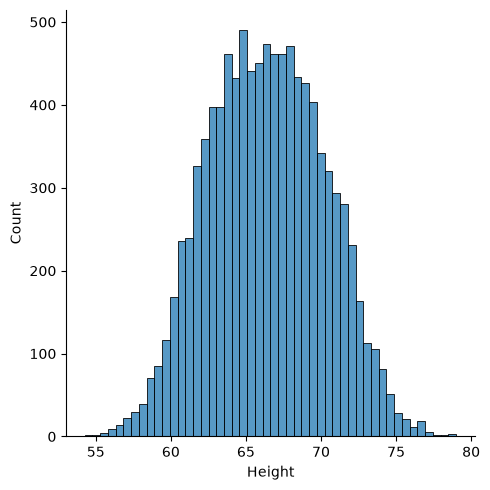

In [7]:
sns.displot(df['Height'])

<Axes: xlabel='Height'>

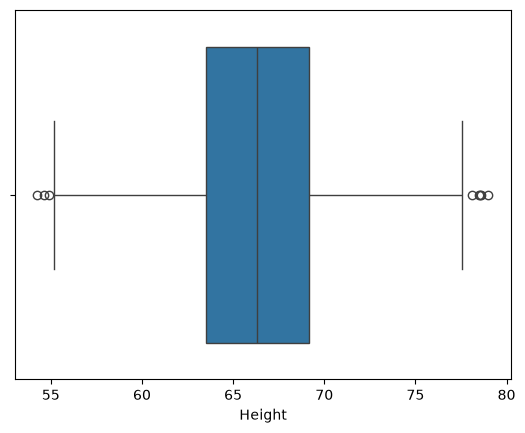

In [10]:
sns.boxplot(df['Height'], orient='h')

In [11]:
upper_limit = df['Height'].quantile(0.99)

In [12]:
upper_limit

np.float64(74.7857900583366)

In [13]:
lower_limit = df['Height'].quantile(0.01)

In [14]:
lower_limit

np.float64(58.13441158671655)

In [17]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [18]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: xlabel='Height'>

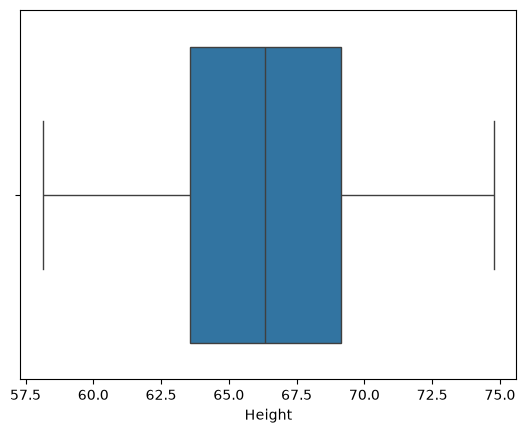

In [19]:
sns.boxplot(new_df['Height'], orient='h')

# Capping (Winsorization)

In [21]:
df['Height'] = np.where(df['Height'] >= upper_limit,
         upper_limit,
         np.where(df['Height'] <= lower_limit,
         lower_limit,
         df['Height']))

In [22]:
df.shape

(10000, 3)

In [23]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


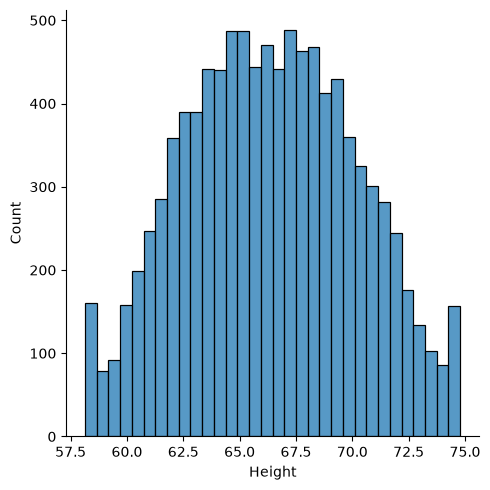

In [24]:
sns.displot(df['Height'])